# Round 1 — Best Bid / Best Ask Over Time

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Load all price files ──────────────────────────────────────────────────────
price_files = sorted(glob.glob('ROUND1/prices_round_1_day_*.csv'))

frames = []
for f in price_files:
    df = pd.read_csv(f, sep=';')
    frames.append(df)

prices = pd.concat(frames, ignore_index=True)
print(f'Loaded {len(prices):,} rows from {len(price_files)} files')
prices.head()

Loaded 60,000 rows from 3 files


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10991.0,15.0,NaN,NaN,NaN,NaN,11006.0,10.0,11009.0,15.0,NaN,NaN,10998.5,0.0
1,-1,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10003.0,29.0,NaN,NaN,NaN,NaN,10003.0,0.0
2,-1,100,ASH_COATED_OSMIUM,9984.0,11.0,NaN,NaN,NaN,NaN,10000.0,11.0,10003.0,22.0,NaN,NaN,9992.0,0.0
3,-1,100,INTARIAN_PEPPER_ROOT,10994.0,9.0,10991.0,21.0,NaN,NaN,11006.0,9.0,11009.0,21.0,NaN,NaN,11000.0,0.0
4,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,20.0,NaN,NaN,10001.0,15.0,10003.0,20.0,NaN,NaN,9993.0,0.0


In [2]:
# ── Derive best bid / best ask per row ───────────────────────────────────────
# Best bid  = maximum of the three bid price levels (ignoring NaN)
# Best ask  = minimum of the three ask price levels (ignoring NaN)

bid_cols = ['bid_price_1', 'bid_price_2', 'bid_price_3']
ask_cols = ['ask_price_1', 'ask_price_2', 'ask_price_3']

prices['best_bid'] = prices[bid_cols].max(axis=1)
prices['best_ask'] = prices[ask_cols].min(axis=1)

# Create a continuous time axis: each day spans 0–999_900 timestamps (step 100)
# Map day -2 → offset 0, day -1 → offset 1_000_000, day 0 → offset 2_000_000
day_order = {d: i for i, d in enumerate(sorted(prices['day'].unique()))}
prices['time'] = prices['day'].map(day_order) * 1_000_000 + prices['timestamp']

products = sorted(prices['product'].unique())
print('Products:', products)

Products: ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']


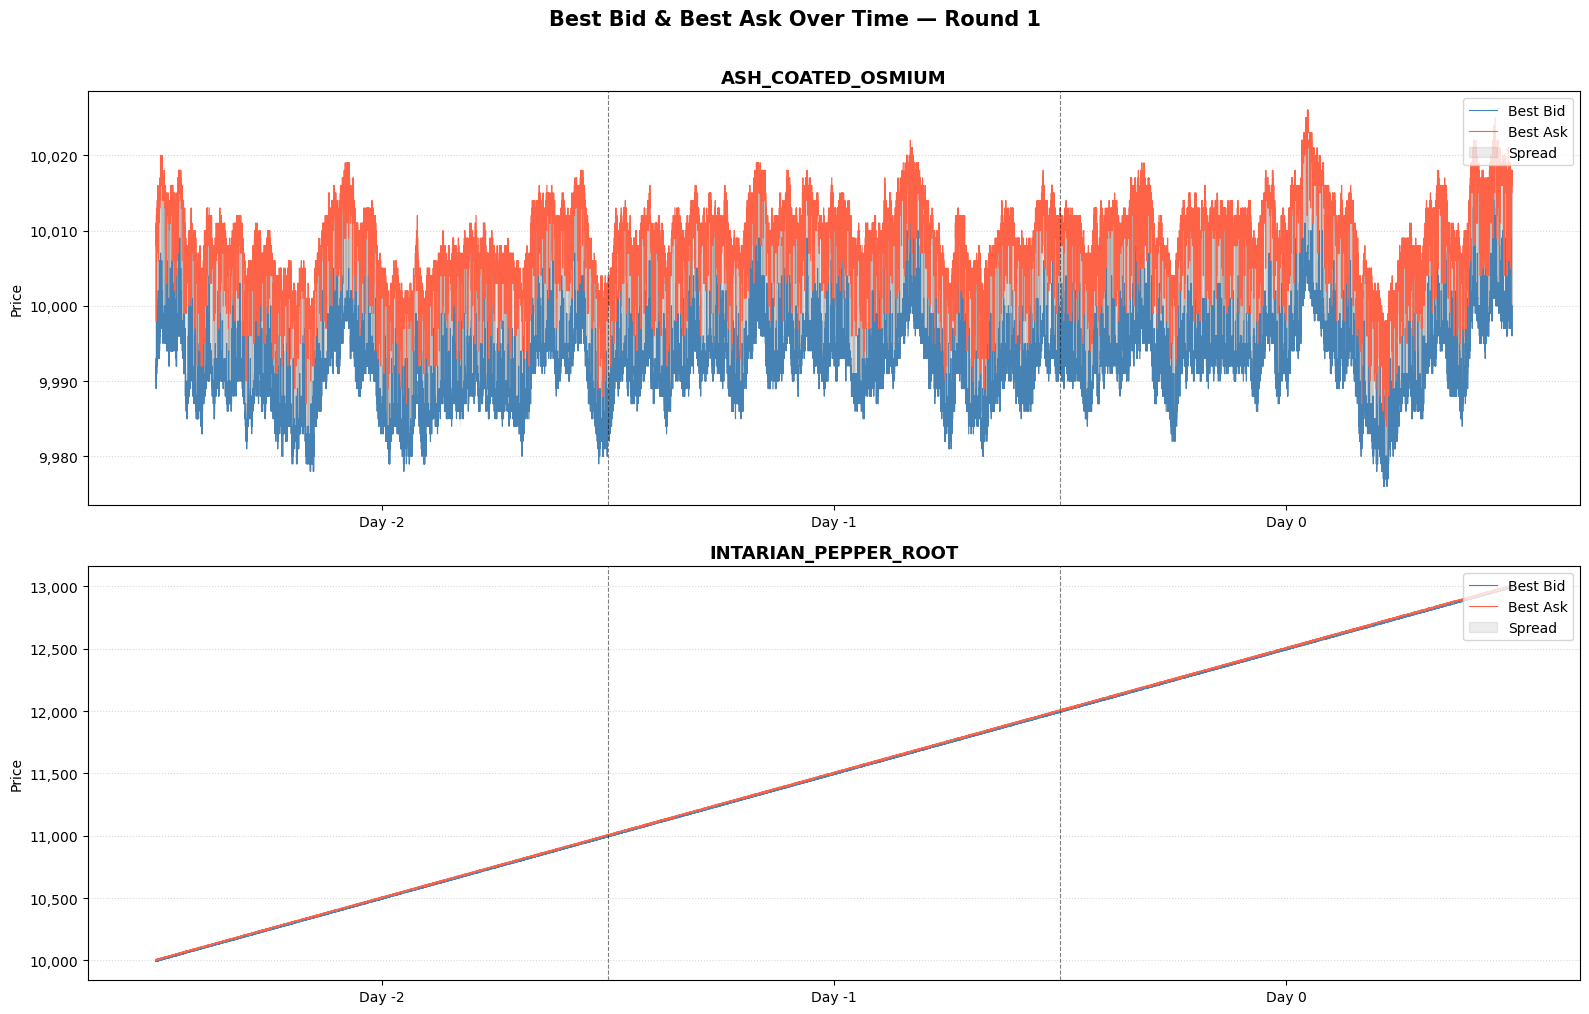

Saved bid_ask_round1.png


In [3]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(products), 1,
                         figsize=(16, 5 * len(products)),
                         sharex=False)

if len(products) == 1:
    axes = [axes]

day_boundaries = [i * 1_000_000 for i in range(len(day_order) + 1)]
sorted_days    = sorted(day_order, key=lambda d: day_order[d])

for ax, product in zip(axes, products):
    sub = prices[prices['product'] == product].sort_values('time')

    ax.plot(sub['time'], sub['best_bid'], label='Best Bid', color='steelblue',  linewidth=0.8)
    ax.plot(sub['time'], sub['best_ask'], label='Best Ask', color='tomato',     linewidth=0.8)
    ax.fill_between(sub['time'], sub['best_bid'], sub['best_ask'],
                    alpha=0.15, color='gray', label='Spread')

    # Day dividers
    for boundary in day_boundaries[1:-1]:
        ax.axvline(boundary, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    # Day labels on x-axis
    tick_positions = [(day_order[d] + 0.5) * 1_000_000 for d in sorted_days]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f'Day {d}' for d in sorted_days], fontsize=10)

    ax.set_title(product, fontsize=13, fontweight='bold')
    ax.set_ylabel('Price')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle('Best Bid & Best Ask Over Time — Round 1', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bid_ask_round1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved bid_ask_round1.png')

## Zoomed-in view — per product, per day (tight y-axis)

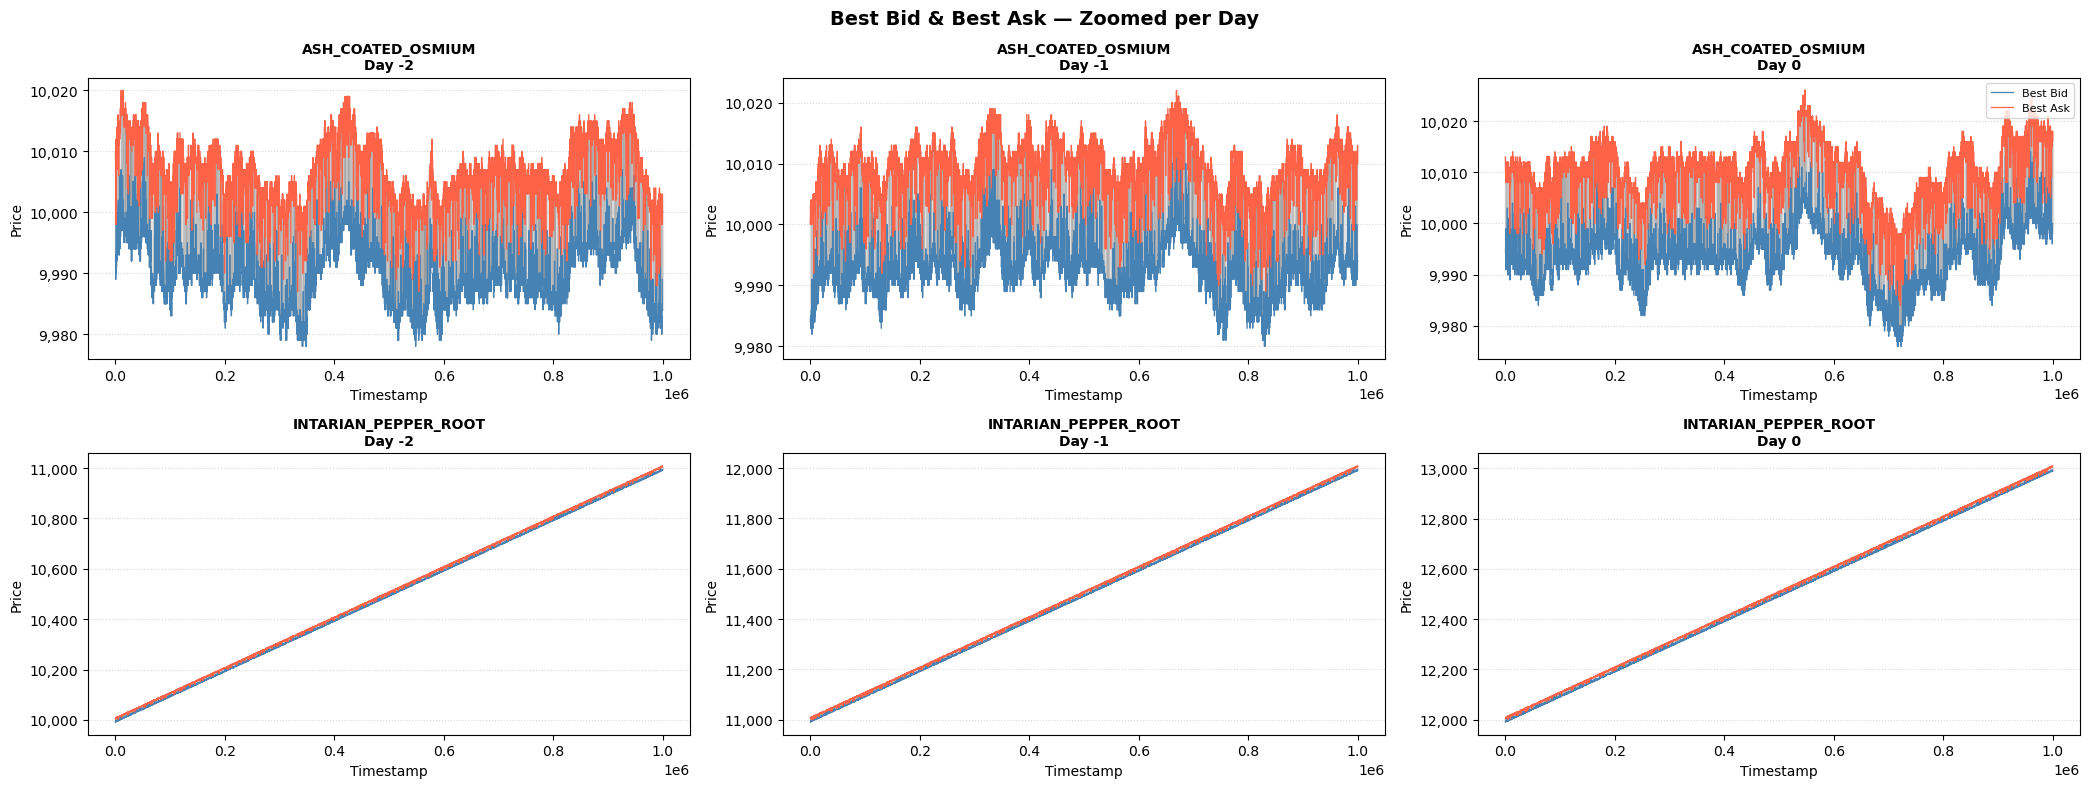

Saved bid_ask_round1_zoomed.png


In [4]:
# ── Zoomed-in: one subplot per (product × day) with a tight y-axis ───────────
sorted_days = sorted(prices['day'].unique())
n_days      = len(sorted_days)

fig, axes = plt.subplots(len(products), n_days,
                         figsize=(7 * n_days, 4 * len(products)),
                         sharex=False, sharey=False)

# Ensure 2-D indexing works even with 1 product or 1 day
if len(products) == 1:
    axes = [axes]
if n_days == 1:
    axes = [[ax] for ax in axes]

for r, product in enumerate(products):
    for c, day in enumerate(sorted_days):
        ax  = axes[r][c]
        sub = (prices[(prices['product'] == product) & (prices['day'] == day)]
               .sort_values('timestamp'))

        if sub.empty:
            ax.set_visible(False)
            continue

        ax.plot(sub['timestamp'], sub['best_bid'], color='steelblue', linewidth=0.9, label='Best Bid')
        ax.plot(sub['timestamp'], sub['best_ask'], color='tomato',    linewidth=0.9, label='Best Ask')
        ax.fill_between(sub['timestamp'], sub['best_bid'], sub['best_ask'],
                        alpha=0.2, color='gray')

        # Tight y-axis: data range + 5 % padding
        lo = min(sub['best_bid'].min(), sub['best_ask'].min())
        hi = max(sub['best_bid'].max(), sub['best_ask'].max())
        pad = (hi - lo) * 0.05 or 1          # fallback if spread == 0
        ax.set_ylim(lo - pad, hi + pad)

        ax.set_title(f'{product}\nDay {day}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Price')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax.grid(axis='y', linestyle=':', alpha=0.5)
        if r == 0 and c == n_days - 1:
            ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Best Bid & Best Ask — Zoomed per Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bid_ask_round1_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved bid_ask_round1_zoomed.png')